**5.1 Эксперименты**
Лабораторная работа 1.1.1


In [38]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import math


0.011542138295885598
0.04401001234329618
0.04549837516767418
3.0055286142965265

0.005386655582965274
0.05294998261148054
0.05322327232447834
1.2469381586932102


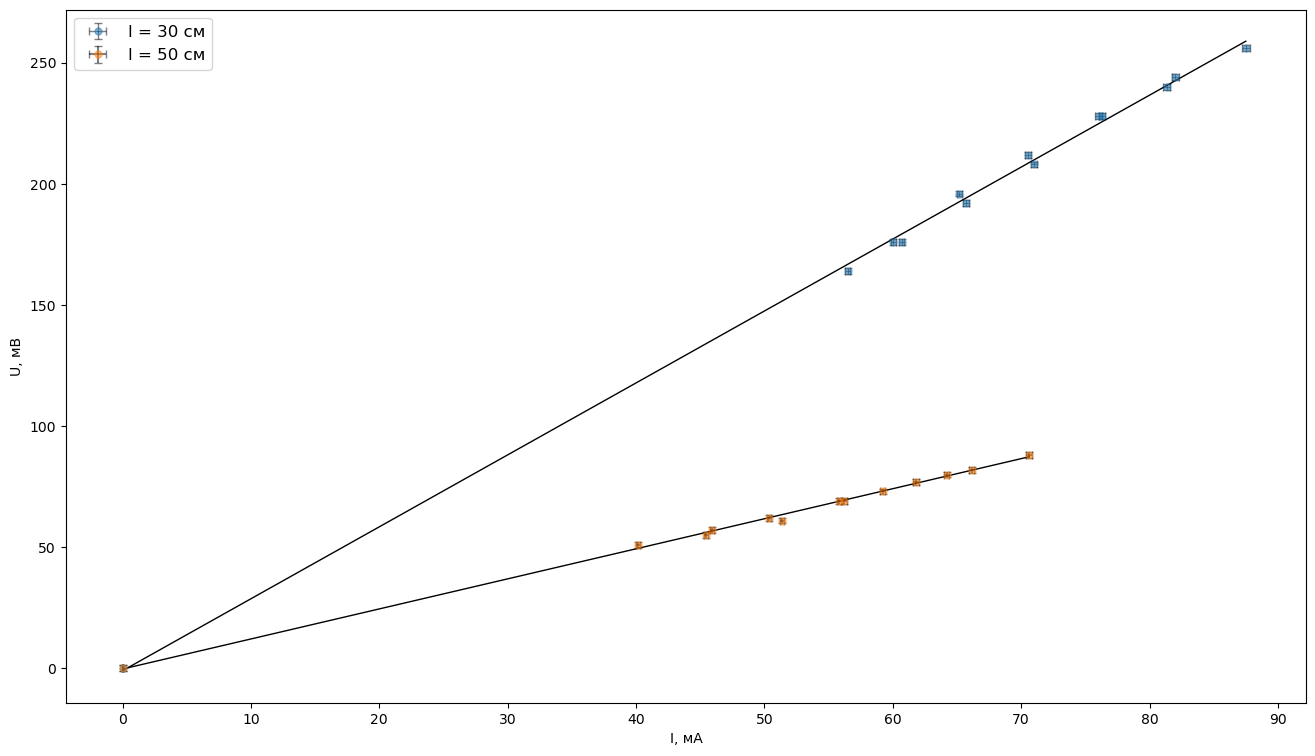

In [39]:
plt.rcParams['figure.figsize'] = (16, 9)
x30=np.array([0,60.05, 65.18, 70.5, 76.02, 81.32, 87.5, 82, 76.3, 71, 65.7, 60.7, 56.5])
y30=np.array([0,176,196,212,228,240,256,244,228,208,192,176,164])

# Use x30 instead of x20 for xerr calculation to ensure matching sizes
plt.errorbar(x30, y30, marker='o', xerr=0.003*x30+0.02, yerr=1.2, 
             linestyle='', ecolor='black', capsize=3, markersize=5, alpha=0.5,
             linewidth=1, label='l = 30 см')

p, v = np.polyfit(x30, y30, deg=1, cov=True)
x=np.arange(min(x30),max(x30),0.01)
plt.plot(x,x*p[0]+p[1],color='black',linewidth=1)
x = 0
y = 0
xy=0
for i in range(len(x30)):
    x+=float(x30[i])**2
    xy+=float(x30[i])*float(y30[i])
    y+=float(y30[i])**2
print(((y/x-xy**2/x**2)/10)**0.5)
print(p[0]*((3.75/max(y30))**2+((0.002*max(x30)+0.02)/max(x30))**2)**0.5)
print(((((y/x-xy**2/x**2)/10)**0.5)**2+(p[0]*((3.75/max(y30))**2+((0.002*max(x30)+0.02)/max(x30))**2)**0.5)**2)**0.5)
print(p[0]*(1+p[0]/250))
print()

# For the second plot (x50, y50)
x50=np.array([0,45.9, 50.36, 55.81, 61.8, 66.13, 70.64, 64.2, 59.2, 56.23, 51.35, 45.41, 40.14])
y50=np.array([0,57,62,69,77,82,88,80,73,69,61,55,51])

# Use x50 instead of x20 for xerr calculation to ensure matching sizes
plt.errorbar(x50, y50, marker='o', xerr=0.003*x50+0.02, yerr=1.2, 
             linestyle='', ecolor='black', capsize=3, markersize=5, alpha=0.5,
             label='l = 50 см')

p, v = np.polyfit(x50, y50, deg=1, cov=True)
x=np.arange(min(x50),max(x50),0.01)
plt.plot(x,x*p[0]+p[1],color='black',linewidth=1)
x = 0
y = 0
xy=0
for i in range(len(x50)):
    x+=float(x50[i])**2
    xy+=float(x50[i])*float(y50[i])
    y+=float(y50[i])**2
print(((y/x-xy**2/x**2)/10)**0.5)
print(p[0]*((3.75/max(y50))**2+((0.002*max(x50)+0.02)/max(x50))**2)**0.5)
print(((((y/x-xy**2/x**2)/10)**0.5)**2+(p[0]*((3.75/max(y50))**2+((0.002*max(x50)+0.02)/max(x50))**2)**0.5)**2)**0.5)
print(p[0]*(1+p[0]/250))

plt.xlabel('I, мА')
plt.ylabel('U, мВ')
plt.legend(fontsize=12)
plt.locator_params(nbins=10)

plt.savefig('рис211.png')

# Add parentheses to actually show the plot
plt.show()

**5.2 Стремление к нормальности**Лабораторная 1.1.4

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from math import gamma

geiger_data = pd.read_csv(r"Мой осн.эксп.csv", header=None)

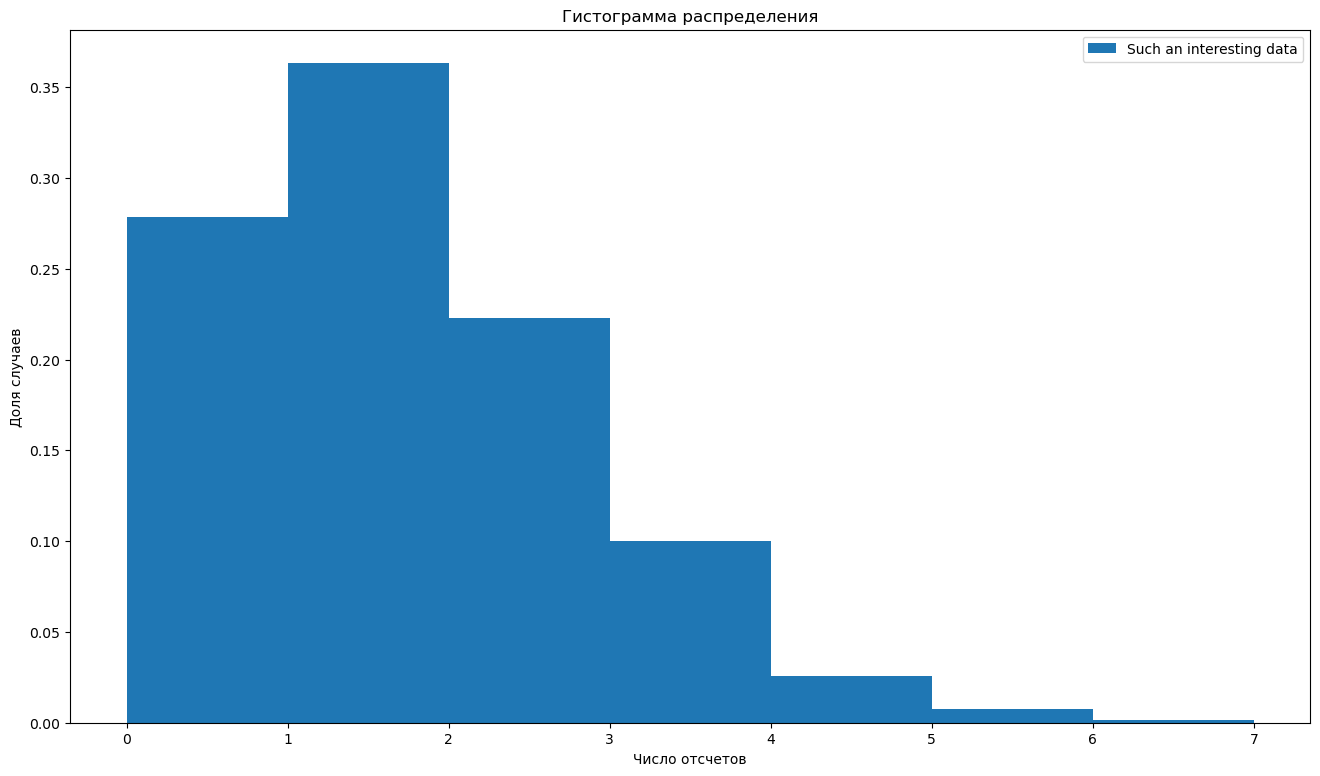

In [41]:
plt.rcParams['figure.figsize'] = (16, 9)
# plt.rcParams['font.size'] = 14

plt.hist(geiger_data[0], bins=range(0, 8, 1), density=True, label='Such an interesting data')
plt.title('Гистограмма распределения')
plt.xlabel('Число отсчетов')
plt.ylabel('Доля случаев')

plt.legend()

plt.show()

125.9


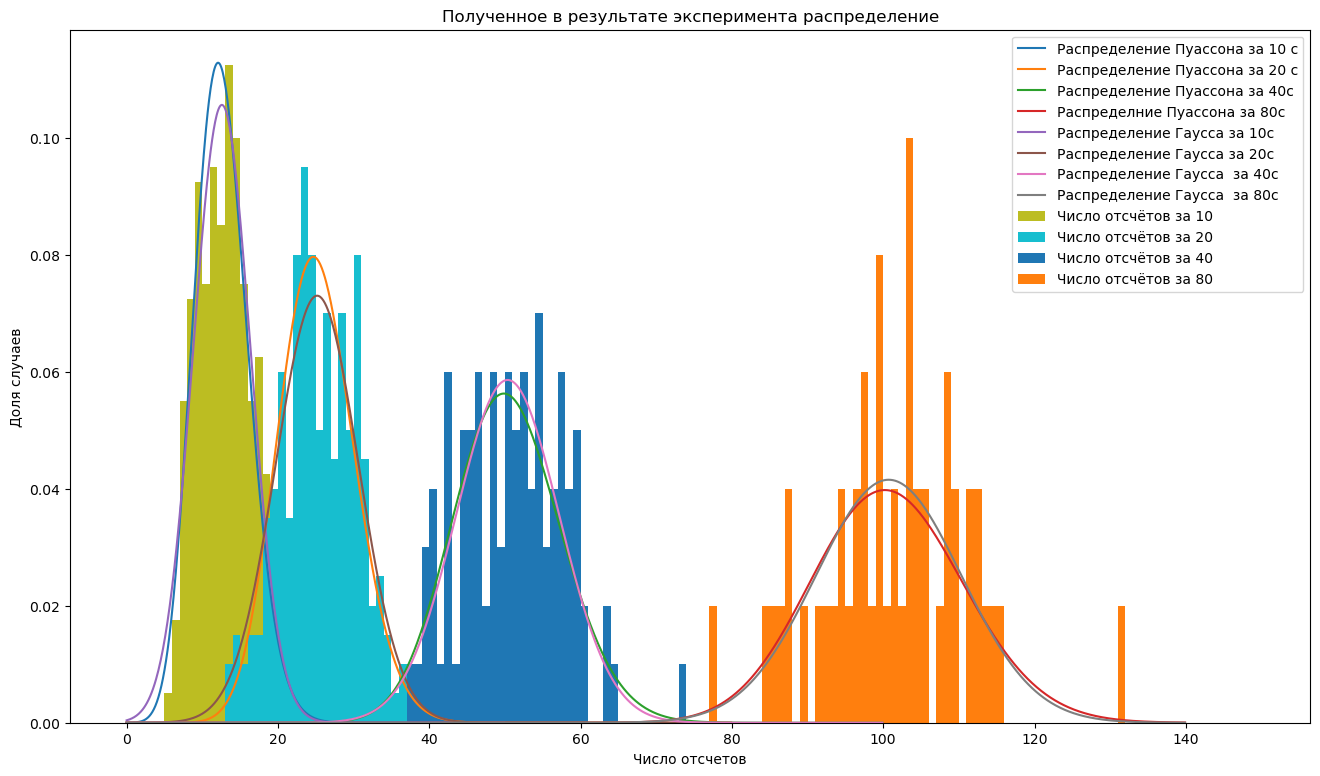

In [42]:



obrabotka = np.array(geiger_data[0])
reshaped_data_1 = np.reshape(obrabotka, ( -1, 10))
reshaped_data_2 = np.reshape(obrabotka, ( -1, 20))
reshaped_data_3 = np.reshape(obrabotka, ( -1, 40))
reshaped_data_4 = np.reshape(obrabotka, ( -1, 80))

def trim_array(arr, n):
    return arr[:len(arr) - len(arr) % n]
reshaped_data_5 = np.reshape(trim_array(obrabotka, 100), ( -1, 100))
# print(reshaped_data_5)

reshaped_sum_1 = np.sum(reshaped_data_1, 1)
reshaped_sum_2 = np.sum(reshaped_data_2, 1)
reshaped_sum_3 = np.sum(reshaped_data_3, 1)
reshaped_sum_4 = np.sum(reshaped_data_4, 1)
reshaped_sum_5 = np.sum(reshaped_data_5, 1)

# sum_data = np.sum(reshaped_obrabotka_1, 1) # 0 суммирует столбцы, 1 - строки




# ЭТО ФУНКЦИЯ НЕПРИЯТНОГО ВИДА ДЛЯ РАСЧЕТА ФАКТОРИАЛА БЕЗ СПЕЦИАЛЬНЫХ БИБЛИОТЕК
def factorial(array):
    return np.array([gamma(val+1) for val in array])

# НАС ИНТЕРЕСУЕТ ТОЛЬКО ФУНКЦИЯ С РАСПРЕДЕЛЕНИЕМ ПУАССОНА
def poisson(n, expected): # Expected -- это аргумент, задающий мат.ожидания распределения
    return expected ** n / factorial(n) * np.exp(-expected)

def gaussian(x, expected, sigma):
    # МЕСТО ДЛЯ ВАШЕГО КОДА
    f= np.exp((-1)*(x-expected)**2/(2*sigma**2))/(np.sqrt(2*np.pi)*sigma)
    return f # И ЭТО ТОЖЕ



x_values1 = np.arange(0, 50, 0.1) 
x_values2 = np.arange(0, 80, 0.1) 
x_values3 = np.arange(0, 100, 0.1) 
x_values4 = np.arange(0, 140, 0.1) 
x_values5 = np.arange(0, 180, 0.1) 

expected_value1 = np.mean(reshaped_sum_1)
expected_value2 = np.mean(reshaped_sum_2)
expected_value3 = np.mean(reshaped_sum_3)
expected_value4 = np.mean(reshaped_sum_4)
expected_value5 = np.mean(reshaped_sum_5)

print(expected_value5)

y_values1_p = poisson(x_values1, expected_value1)
y_values2_p = poisson(x_values2, expected_value2)
y_values3_p = poisson(x_values3, expected_value3)
y_values4_p = poisson(x_values4, expected_value4)
# y_values5_p = poisson(x_values5, expected_value5)

sigma1=np.std(reshaped_sum_1)
sigma2=np.std(reshaped_sum_2)
sigma3=np.std(reshaped_sum_3)
sigma4=np.std(reshaped_sum_4)
sigma5=np.std(reshaped_sum_5)

y_values1_g=gaussian(x_values1, np.mean(reshaped_sum_1), sigma1)
y_values2_g=gaussian(x_values2, np.mean(reshaped_sum_2), sigma2)
y_values3_g=gaussian(x_values3, np.mean(reshaped_sum_3), sigma3)
y_values4_g=gaussian(x_values4, np.mean(reshaped_sum_4), sigma4)
# y_values5_g=gaussian(x_values5, np.mean(reshaped_sum_5), sigma5)









plt.plot(x_values1, y_values1_p, label='Распределение Пуассона за 10 с')
plt.plot(x_values2, y_values2_p, label='Распределение Пуассона за 20 с')
plt.plot(x_values3, y_values3_p, label='Распределение Пуассона за 40с')
plt.plot(x_values4, y_values4_p, label='Распределние Пуассона за 80с')

# plt.plot(x_values5, y_values5_p, label='Poisson distribution for 100 seconds')

plt.plot(x_values1, y_values1_g, label='Распределение Гаусса за 10с')
plt.plot(x_values2, y_values2_g, label='Распределение Гаусса за 20с')
plt.plot(x_values3, y_values3_g, label='Распределение Гаусса  за 40с')
plt.plot(x_values4, y_values4_g, label='Распределение Гаусса  за 80с')
# plt.plot(x_values5, y_values5_g, label='Gaussian 100 sec')


plt.hist(np.sum(reshaped_data_1, 1), bins=range(0, 150, 1), label='Число отсчётов за 10', density=True)
plt.hist(np.sum(reshaped_data_2, 1), bins=range(0, 150, 1), label='Число отсчётов за 20', density=True)
plt.hist(np.sum(reshaped_data_3, 1), bins=range(0, 150, 1), label='Число отсчётов за 40', density=True)
plt.hist(np.sum(reshaped_data_4, 1), bins=range(0, 150, 1), label='Число отсчётов за 80', density=True)
# plt.hist(np.sum(reshaped_data_5, 1), bins=range(0, 150, 1), label='Geiger data, 100 sec', density=True)


plt.title('Полученное в результате эксперимента распределение')
plt.xlabel('Число отсчетов')
plt.ylabel('Доля случаев')

# plt.legend()
plt.legend()



plt.show()
# print(np.sum(reshaped_data_1, 1))

**Вот такие пироги**

Ellipsis

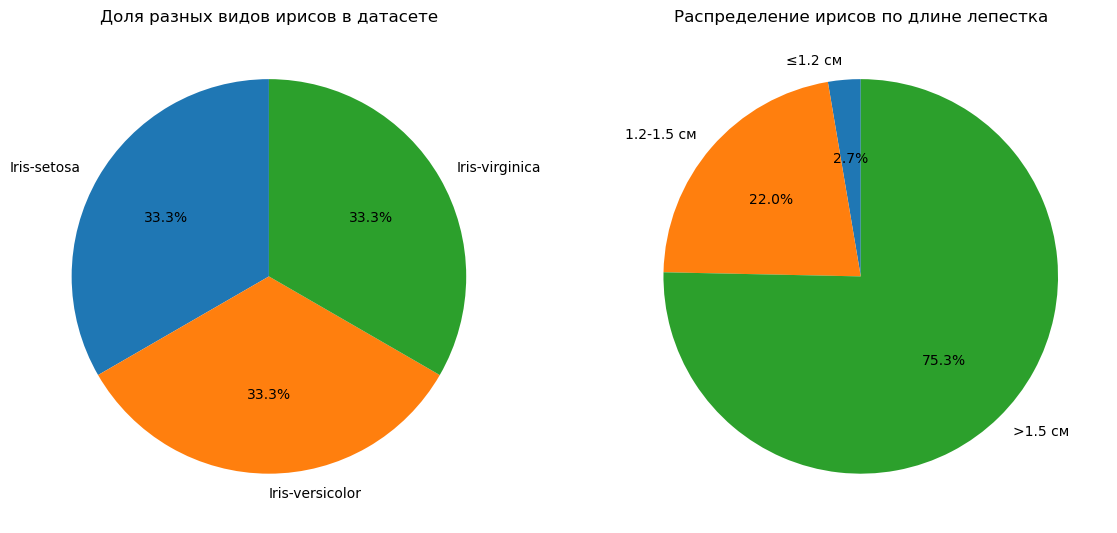

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('iris_data.csv')

# Создание фигуры с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Первая круговая диаграмма: распределение по видам ирисов
species_counts = df['Species'].value_counts()
plt.subplot(1, 2, 1)
species_counts = df['Species'].value_counts()
plt.pie(species_counts.values, labels=species_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Доля разных видов ирисов в датасете')



# Вторая круговая диаграмма: распределение по длине лепестка
plt.subplot(1, 2, 2)

petal_length = df['PetalLengthCm']
cat_1 = len(petal_length[petal_length <= 1.2])  # <= 1.2 см
cat_2 = len(petal_length[(petal_length > 1.2) & (petal_length <= 1.5)])  # >1.2 и <=1.5 см
cat_3 = len(petal_length[petal_length > 1.5])  # > 1.5 см

categories = ['≤1.2 см', '1.2-1.5 см', '>1.5 см']
counts = [cat_1, cat_2, cat_3]

plt.pie(counts, labels=categories, autopct='%1.1f%%', startangle=90)
plt.title('Распределение ирисов по длине лепестка')


...

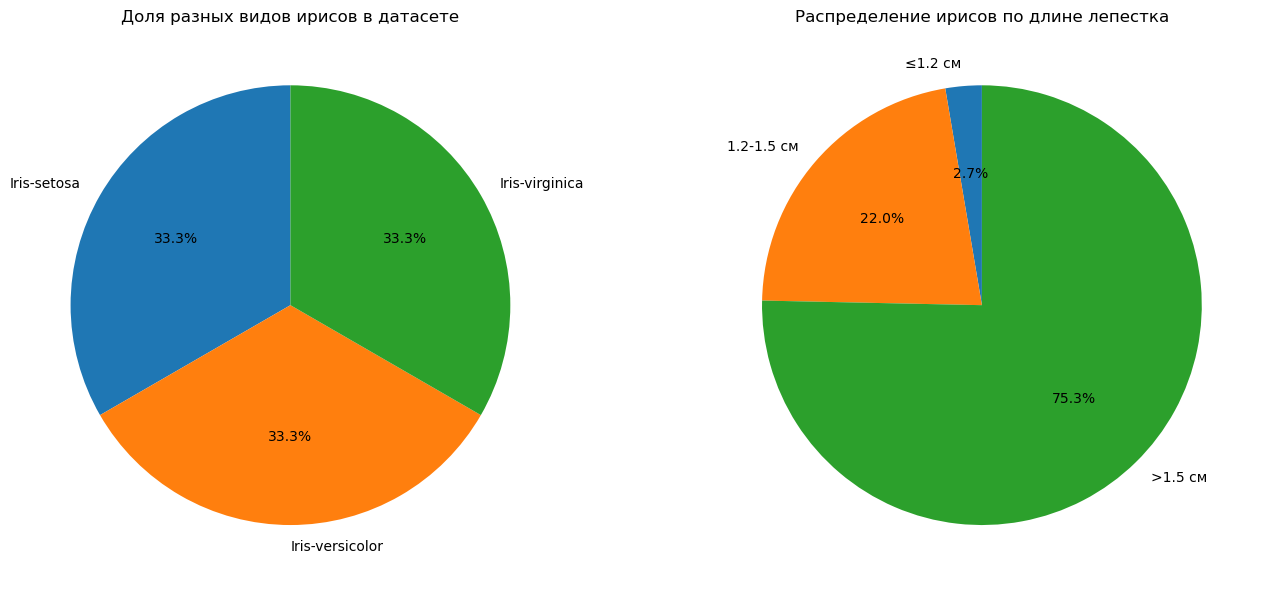

In [44]:
# Загрузка данных
df = pd.read_csv('iris_data.csv')

# Первая круговая диаграмма: доля разных видов ирисов
plt.figure(figsize=(14, 6))

# Подграфик 1: Доля видов ирисов
plt.subplot(1, 2, 1)
species_counts = df['Species'].value_counts()
plt.pie(species_counts.values, labels=species_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Доля разных видов ирисов в датасете')

# Вторая круговая диаграмма: распределение по длине лепестка
plt.subplot(1, 2, 2)

# Категории по длине лепестка
petal_length = df['PetalLengthCm']
category_1 = len(petal_length[petal_length <= 1.2])  # <= 1.2 см
category_2 = len(petal_length[(petal_length > 1.2) & (petal_length <= 1.5)])  # >1.2 и <=1.5 см
category_3 = len(petal_length[petal_length > 1.5])  # > 1.5 см

categories = ['≤1.2 см', '1.2-1.5 см', '>1.5 см']
counts = [category_1, category_2, category_3]

plt.pie(counts, labels=categories, autopct='%1.1f%%', startangle=90)
plt.title('Распределение ирисов по длине лепестка')

# Настройка отображения
plt.tight_layout()
plt.show()



**5.8**

In [45]:

list1=[1,2,5,6,9]
list2=[3,5,6,7,10,0]

set1 = set(list1)
set2 = set(list2)
    


union = set1 | set2
print("Объединение (A | B):",sorted(union))
    

intersection = set1 & set2
print("Пересечение (A & B):", sorted(intersection))
    

difference1 = set1 - set2
print("Разность A - B:",sorted(difference1))
    

difference2 = set2 - set1
print("Разность B - A:", sorted(difference2))

symmetric = set1 ^ set2
print("Симметрическая разность (A ^ B):",sorted(symmetric))
    



Объединение (A | B): [0, 1, 2, 3, 5, 6, 7, 9, 10]
Пересечение (A & B): [5, 6]
Разность A - B: [1, 2, 9]
Разность B - A: [0, 3, 7, 10]
Симметрическая разность (A ^ B): [0, 1, 2, 3, 7, 9, 10]


**5.7**( до конца не получилось решить,но вот часть кода.)

In [ ]:
import string

def count_words_with_max(filename):
    # Чтение файла
    with open(filename, 'r', encoding='utf-8') as file:
            text = file.read()

word_count = {}
count_words_with_max("PYTHON-LICENSE.txt")            

    # Подготовка текста
translator = str.maketrans('', '', string.punctuation)
cleaned_text=text.translate(translator).lower()
print(cleaned_text)
    # Разделение на слова

words = cleaned_text.split()
            
for word in words:
      word_count[word] = word_count.get(word, 0) + 1

print(words)



def find_top_10_words(word_count):
  
 
    temp_dict = word_count.copy()
    top_words = []
    
    # Находим 10 максимальных элементов
   
            
    max_word = None
    max_count = 0
        
        # Пробегаем по всем ключам и находим максимальный
    for word in temp_dict:
         count = temp_dict[word]
         if count > max_count:
             max_count = count
             max_word = word
        
       
         if max_word:
            top_words.append((max_word))
            del temp_dict[max_word]
    
    return top_words

print(find_top_10_words(word_count))


NameError: name 'text' is not defined